<a href="https://colab.research.google.com/github/jtriana645-lgtm/applied-math-repository/blob/main/hotelling_t2_mc_arl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multivariate Statistical Quality Control: Hotelling's T^2 Chart with Monte Carlo ARL Simulation

This project implements a multivariate statistical process control scheme using Hotelling's $T^2$ control statistic with a two-signal run rule (RL2). It evaluates the Average Run Length (ARL) through Monte Carlo simulation and validates the generated multivariate normal distributions.

## Problem Description

In multivariate quality control, monitoring multiple correlated variables simultaneously is required to detect process shifts. Hotelling's $T^2$ statistic generalizes Student's $t$-statistic for multivariate observations.

For sample size $m$, sample mean vector $\bar{\mathbf{x}}$, target mean vector $\boldsymbol{\mu}_0$, and known covariance matrix $\boldsymbol{\Sigma}$, the $T^2$ control statistic is calculated as:

$$T^2 = m (\bar{\mathbf{x}} - \boldsymbol{\mu}_0)^T \boldsymbol{\Sigma}^{-1} (\bar{\mathbf{x}} - \boldsymbol{\mu}_0)$$

Under control conditions, $T^2$ follows a chi-squared distribution $\chi^2_p$, where $p$ is the number of monitored variables. The upper control limit (UCL) $h$ is set at significance level $\alpha$:

$$h = \chi^2_{1-\alpha, p}$$

### RL2 Run Rule Scheme
To reduce false alarms or detect persistent shifts, an RL2 decision rule is applied: process out-of-control condition is triggered only when two consecutive signals occur within a window of $\text{lim}$ samples.

## Implementation Details

The code generates bivariate normal samples $N(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, computes $T^2$ values sequentially, applies the RL2 triggering criterion across $N_{\text{sim}} = 2000$ iterations, and validates sample marginal distributions using histogram fittings.

In [ ]:
import numpy as np
from scipy.stats import chi2

np.random.seed(123)

num_va = 2
tsub_m = 5
alpha = 0.005
lim = 3
N_sim = 2000

mu_0 = np.zeros(num_va)

Sigma = np.array([[1.0, 0.5],
                  [0.5, 1.0]])
Sigma_inv = np.linalg.inv(Sigma)

h = chi2.ppf(1 - alpha, df=num_va)

def T2_hotelling(xbar):
    d = xbar - mu_0
    return tsub_m * d.T @ Sigma_inv @ d

def ARL_T2_RL2_MC(mu_real):
    RL = []
    for _ in range(N_sim):
        j = 0
        ultima_s = None
        while True:
            j += 1
            muestra = np.random.multivariate_normal(mu_real, Sigma, tsub_m)
            xbar = muestra.mean(axis=0)
            señal = T2_hotelling(xbar) > h
            if señal:
                if ultima_s is not None:
                    if j - ultima_s <= lim:
                        RL.append(j)
                        break
                ultima_s = j

    return np.mean(RL)

arl_rl2 = ARL_T2_RL2_MC(mu_0)
print("ARL T²–RL2 (Monte Carlo):", arl_rl2)


ARL T²–RL2 (Monte Carlo): 13567.8675


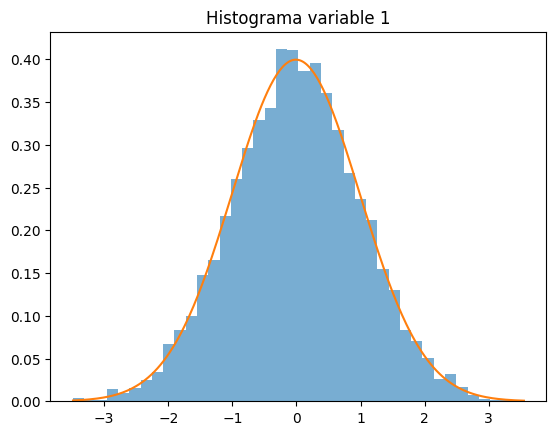

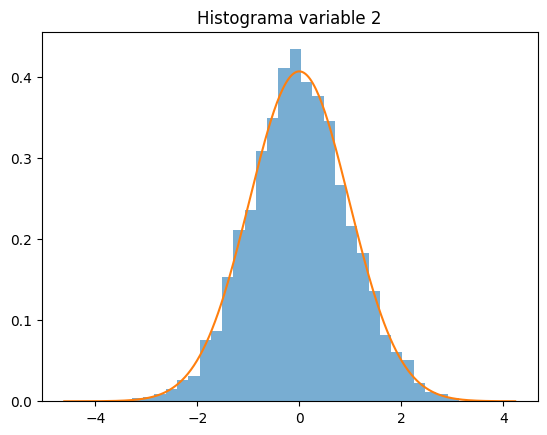

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm

X = np.random.multivariate_normal(mu_0, Sigma, size=5000)

for i in range(X.shape[1]):
    plt.figure()
    plt.hist(X[:, i], bins=40, density=True, alpha=0.6)

    x = np.linspace(X[:, i].min(), X[:, i].max(), 300)
    plt.plot(x, norm.pdf(x, np.mean(X[:, i]), np.std(X[:, i])))

    plt.title(f"Histograma variable {i+1}")
    plt.show()
